## ----- PROJET: Détection de Spam SMS avec Réduction de Dimensionalité ------


OBJECTIFS:
1. Prétraiter et nettoyer des SMS (ham/spam)
2. Vectoriser avec TF-IDF
3. Réduire la dimensionalité avec un Autoencodeur
4. Utiliser la Cross-Validation pour une évaluation robuste
5. Utilisation d'un modele pré entrainé (Bert ou autre)

ÉTAPES PRINCIPALES:
- Chargement et nettoyage des données
- Vectorisation TF-IDF
- Réduction de dimensionalité (Autoencodeur)
- Classification avec Cross-Validation
- Comparaison avec BERT

ÉTAPE 1: IMPORTATION DES BIBLIOTHÈQUES

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, make_scorer
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense,Dropout
from tensorflow.keras.optimizers import Adam

# Pour BERT avec TensorFlow
#from transformers import AutoTokenizer, TFAutoModel




print("✓ Toutes les bibliothèques importées avec succès")



✓ Toutes les bibliothèques importées avec succès


ÉTAPE 2: CHARGEMENT ET EXPLORATION DES DONNÉES

In [16]:
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "text"])

print(f"✓ Dataset chargé: {df.shape[0]} messages")
print(f"  - Ham (légitimes): {(df['label'] == 'ham').sum()} ({(df['label'] == 'ham').sum()/len(df)*100:.1f}%)")
print(f"  - Spam: {(df['label'] == 'spam').sum()} ({(df['label'] == 'spam').sum()/len(df)*100:.1f}%)")


✓ Dataset chargé: 5572 messages
  - Ham (légitimes): 4825 (86.6%)
  - Spam: 747 (13.4%)


ÉTAPE 3: PRÉTRAITEMENT DU TEXTE

In [17]:
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Nettoie et normalise le texte:
    1. Conversion en minuscules
    2. Suppression des caractères non-alphabétiques
    3. Suppression des stopwords
    4. Stemming
    """
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in english_stopwords]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)
df_clean_export = df[["label", "clean_text"]].copy()
df_clean_export.to_csv("sms_clean.csv", index=False)

print("✓ Textes nettoyés et exportés vers 'sms_clean.csv'")

✓ Textes nettoyés et exportés vers 'sms_clean.csv'


ÉTAPE 4: SÉPARATION TRAIN/TEST ET VECTORISATION TF-IDF

In [18]:
X = df["clean_text"].values
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f"✓ Vectorisation complétée")
print(f"  - Dimensions train: {X_train_tfidf.shape}")
print(f"  - Dimensions test: {X_test_tfidf.shape}")

# Conversion pour l'autoencodeur
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()


✓ Vectorisation complétée
  - Dimensions train: (4457, 5000)
  - Dimensions test: (1115, 5000)


ÉTAPE 5: CONSTRUCTION ET ENTRAÎNEMENT DE L'AUTOENCODEUR

In [19]:
input_dim = X_train_dense.shape[1]
latent_dim = 128

# Architecture
input_layer = Input(shape=(input_dim,), name="input_layer")

# Encodeur
encoded = Dense(512, activation='relu', name="encoder_1")(input_layer)
encoded = Dropout(0.2)(encoded)
encoded = Dense(256, activation='relu', name="encoder_2")(encoded)
encoded = Dropout(0.2)(encoded)
latent = Dense(latent_dim, activation='relu', name="latent_space")(encoded)

# Décodeur
decoded = Dense(256, activation='relu', name="decoder_1")(latent)
decoded = Dropout(0.2)(decoded)
decoded = Dense(512, activation='relu', name="decoder_2")(decoded)
decoded = Dropout(0.2)(decoded)
output_layer = Dense(input_dim, activation='sigmoid', name="output_layer")(decoded)

# Modèles
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="autoencoder")
encoder = Model(inputs=input_layer, outputs=latent, name="encoder")

autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

print("✓ Architecture de l'Autoencodeur:")
print(f"  - Input: {input_dim} features")
print(f"  - Couches cachées: 512 → 256 → {latent_dim} (latent)")
print(f"  - Reconstruction: {latent_dim} → 256 → 512 → {input_dim}")

✓ Architecture de l'Autoencodeur:
  - Input: 5000 features
  - Couches cachées: 512 → 256 → 128 (latent)
  - Reconstruction: 128 → 256 → 512 → 5000


Etape6 : Entrainement de l'encodeur 

✓ Entraînement terminé (5 epochs)
✓ Graphique sauvegardé: 'autoencoder_loss.png'


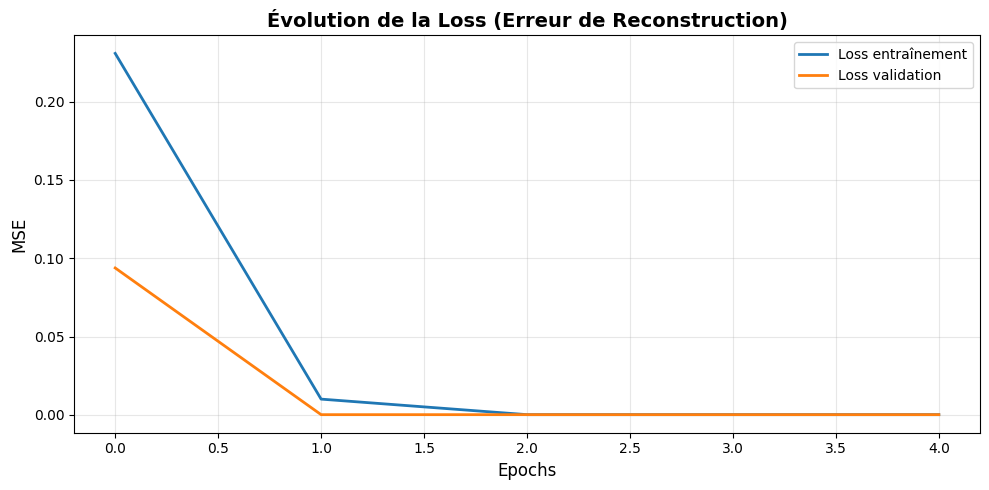

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_train_dense, X_train_dense,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

print(f"✓ Entraînement terminé ({len(history.history['loss'])} epochs)")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss entraînement', linewidth=2)
plt.plot(history.history['val_loss'], label='Loss validation', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title("Évolution de la Loss (Erreur de Reconstruction)", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('autoencoder_loss.png', dpi=150, bbox_inches='tight')
print("✓ Graphique sauvegardé: 'autoencoder_loss.png'")
plt.show()

Etape 7: COMPRESSION AVEC L'ENCODEUR 

In [21]:
X_train_encoded = encoder.predict(X_train_dense, verbose=0)
X_test_encoded = encoder.predict(X_test_dense, verbose=0)

print(f"✓ Compression réussie: {input_dim} → {latent_dim} dimensions")

✓ Compression réussie: 5000 → 128 dimensions


Etape 8: FONCTION D'ÉVALUATION AVEC CROSS-VALIDATION

In [22]:
def evaluate_with_cv(X_train, y_train, model_name, C=1.0, class_weight=None, penalty='l2', solver='lbfgs'):
    """
    Évalue un modèle avec Cross-Validation (5-fold stratifié)
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    clf = LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        C=C, 
        class_weight=class_weight,
        penalty=penalty,
        solver=solver
    )
    
    # Scorers personnalisés
    scoring = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score, pos_label='spam', zero_division=0),
        'recall': make_scorer(recall_score, pos_label='spam', zero_division=0),
        'f1': make_scorer(f1_score, pos_label='spam', zero_division=0)
    }
    
    # Cross-validation
    results = {}
    for metric_name, scorer in scoring.items():
        scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1)
        results[metric_name] = {
            'mean': scores.mean(),
            'std': scores.std()
        }
    
    # Affichage
    print(f"\n{model_name}:")
    print(f"  (Params: C={C}, Penalty='{penalty}', Solver='{solver}')")
    print(f"  Accuracy:  {results['accuracy']['mean']:.4f} (±{results['accuracy']['std']:.4f})")
    print(f"  Precision: {results['precision']['mean']:.4f} (±{results['precision']['std']:.4f})")
    print(f"  Recall:    {results['recall']['mean']:.4f} (±{results['recall']['std']:.4f})")
    print(f"  F1-Score:  {results['f1']['mean']:.4f} (±{results['f1']['std']:.4f})")
    
    return results

 CELLULE 9: OPTIMISATION AVEC GRIDSEARCH

In [23]:
print("##  Optimisation des Hyperparamètres avec GridSearchCV ##\n")

# Configuration CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_spam = make_scorer(f1_score, pos_label='spam')

    # GridSearch pour Autoencodeur
clf_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
param_grid = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_search_ae = GridSearchCV(
    estimator=clf_base, 
    param_grid=param_grid, 
    scoring=f1_spam,
    cv=cv,
    refit=True, 
    verbose=1, 
    n_jobs=-1
)

grid_search_ae.fit(X_train_encoded, y_train)

# Extraction des meilleurs paramètres
best_params_ae = grid_search_ae.best_params_
best_C_ae = best_params_ae['C']
best_penalty_ae = best_params_ae['penalty']
best_solver_ae = best_params_ae['solver']

print(f"\n✓ Optimisation Autoencodeur terminée.")
print(f"  - Meilleurs paramètres: C={best_C_ae}, Penalty={best_penalty_ae}, Solver={best_solver_ae}")
print(f"  - Meilleur F1-Score CV: {grid_search_ae.best_score_:.4f}")

# Évaluation avec les meilleurs paramètres
results_ae_optimized = evaluate_with_cv(
    X_train_encoded, y_train, 
    f"Autoencodeur ({X_train_encoded.shape[1]} features) - OPTIMISÉ",
    C=best_C_ae,
    class_weight='balanced',
    penalty=best_penalty_ae,
    solver=best_solver_ae
)

# Évaluation TF-IDF Brut (référence)
results_tfidf_balanced = evaluate_with_cv(
    X_train_tfidf, y_train, 
    "TF-IDF Brut (5000 features) - BALANCED", 
    class_weight='balanced'
)

##  Optimisation des Hyperparamètres avec GridSearchCV ##

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ Optimisation Autoencodeur terminée.
  - Meilleurs paramètres: C=100, Penalty=l2, Solver=liblinear
  - Meilleur F1-Score CV: 0.6286

Autoencodeur (128 features) - OPTIMISÉ:
  (Params: C=100, Penalty='l2', Solver='liblinear')
  Accuracy:  0.8676 (±0.0140)
  Precision: 0.5050 (±0.0304)
  Recall:    0.8328 (±0.0322)
  F1-Score:  0.6286 (±0.0317)

TF-IDF Brut (5000 features) - BALANCED:
  (Params: C=1.0, Penalty='l2', Solver='lbfgs')
  Accuracy:  0.9780 (±0.0027)
  Precision: 0.9171 (±0.0190)
  Recall:    0.9197 (±0.0128)
  F1-Score:  0.9182 (±0.0098)


Partie 10: FONCTION D'ÉVALUATION FINALE 

In [24]:
def evaluate_final_model(X_train, X_test, y_train, y_test, model_name, C=1.0, 
                        class_weight=None, penalty='l2', solver='lbfgs'):
    """
    Entraîne le modèle final et évalue sur le test set
    """
    clf = LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        C=C, 
        class_weight=class_weight,
        penalty=penalty,
        solver=solver
    )
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    print(f"\n{model_name}:\n")
    print(f"(Params: C={C}, Penalty='{penalty}', Solver='{solver}')")
    
    print("\nMatrice de Confusion:")
    cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
    print(cm)
    
    print("\nRapport de Classification:")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))
    
    # Visualisation de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["ham", "spam"], 
                yticklabels=["ham", "spam"])
    plt.title(f'Matrice de Confusion - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    
    # Sauvegarde
    filename = f"confusion_matrix_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✓ Matrice sauvegardée: '{filename}'")
    plt.show()
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label='spam'),
        'recall': recall_score(y_test, y_pred, pos_label='spam'),
        'f1': f1_score(y_test, y_pred, pos_label='spam')
    }


Partie 11: ÉVALUATION FINALE SUR TEST SET


##  Résultats de l'Évaluation Finale sur le Test Set ##

Autoencodeur (OPTIMISÉ):

(Params: C=100, Penalty='l2', Solver='liblinear')

Matrice de Confusion:
[[838 128]
 [ 26 123]]

Rapport de Classification:
              precision    recall  f1-score   support

         ham       0.97      0.87      0.92       966
        spam       0.49      0.83      0.61       149

    accuracy                           0.86      1115
   macro avg       0.73      0.85      0.77      1115
weighted avg       0.91      0.86      0.88      1115


✓ Matrice sauvegardée: 'confusion_matrix_Autoencodeur_OPTIMISÉ.png'


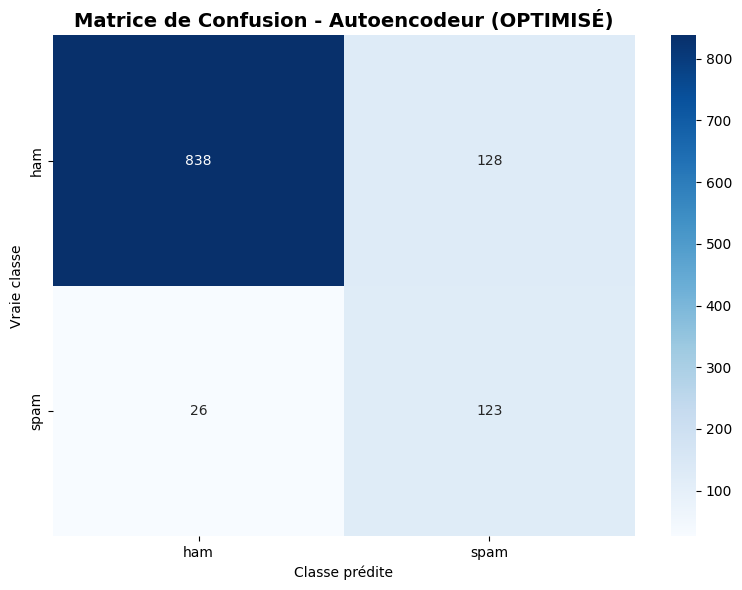


TF-IDF Brut (BALANCED):

(Params: C=1.0, Penalty='l2', Solver='lbfgs')

Matrice de Confusion:
[[956  10]
 [ 12 137]]

Rapport de Classification:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.93      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


✓ Matrice sauvegardée: 'confusion_matrix_TF-IDF_Brut_BALANCED.png'


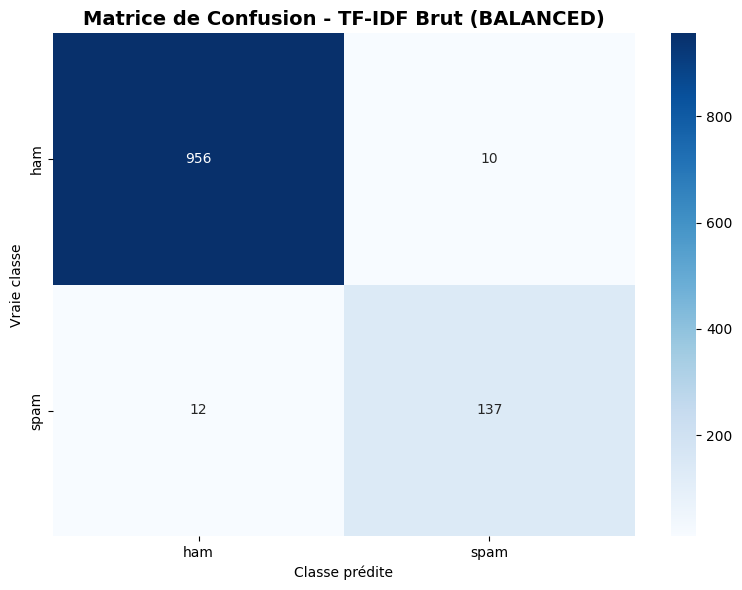

In [25]:
print("\n##  Résultats de l'Évaluation Finale sur le Test Set ##")

# 1. Autoencodeur optimisé
final_ae_optimized = evaluate_final_model(
    X_train_encoded, X_test_encoded, y_train, y_test, 
    "Autoencodeur (OPTIMISÉ)",
    C=best_C_ae, 
    class_weight='balanced',
    penalty=best_penalty_ae, 
    solver=best_solver_ae
)

# 2. TF-IDF Brut
final_tfidf_balanced = evaluate_final_model(
    X_train_tfidf, X_test_tfidf, y_train, y_test, 
    "TF-IDF Brut (BALANCED)",
    C=1.0, 
    class_weight='balanced'
)


In [ ]:
print("##  Optimisation des Hyperparamètres avec GridSearchCV (AMÉLIORÉ) ##\n")

# Configuration CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# AMÉLIORATION 1: Scorer personnalisé pour pénaliser les faux positifs
# ============================================================================
def custom_scorer(y_true, y_pred):
    """
    Scorer qui pénalise fortement les faux positifs (hams bloqués)
    tout en encourageant une bonne détection du spam
    """
    from sklearn.metrics import confusion_matrix
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=['ham', 'spam']).ravel()
    
    # Coûts: Bloquer un ham est 5x pire que laisser passer un spam
    cost = -5 * fp - fn  # Plus le score est élevé, mieux c'est
    
    # Normaliser par le nombre total
    normalized_cost = cost / len(y_true)
    
    return normalized_cost

custom_score = make_scorer(custom_scorer, greater_is_better=True)

# ============================================================================
# AMÉLIORATION 2: Grid de paramètres élargi et plus intelligent
# ============================================================================
param_grid_improved = {
    'C': [50, 100, 200],  # Plus de granularité, inclut valeurs plus basses
    'penalty': ['l2'],  # L1 pour feature selection automatique
    'solver': ['liblinear', 'saga'],  # saga supporte l1 et l2
    'class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 15}]  # Surpondérer le spam
}

# ============================================================================
# AMÉLIORATION 3: Plusieurs stratégies de scoring
# ============================================================================
scoring_strategies = {
    'custom_cost': custom_score,
    'f1_spam': make_scorer(f1_score, pos_label='spam'),
    'recall_spam': make_scorer(recall_score, pos_label='spam'),
    'precision_ham': make_scorer(precision_score, pos_label='ham')
}

print("🔍 Stratégie 1: Minimiser le coût (pénaliser faux positifs)")
print("=" * 60)

clf_base = LogisticRegression(max_iter=2000, random_state=42)

grid_search_cost = GridSearchCV(
    estimator=clf_base,
    param_grid=param_grid_improved,
    scoring=scoring_strategies['custom_cost'],
    cv=cv,
    refit=True,
    verbose=2,
    n_jobs=-1
)

grid_search_cost.fit(X_train_encoded, y_train)

print(f"\n✓ Meilleurs paramètres (minimisation coût):")
print(f"  {grid_search_cost.best_params_}")
print(f"  Score: {grid_search_cost.best_score_:.4f}")

# ============================================================================
# AMÉLIORATION 4: Optimisation multi-objectif avec seuil ajustable
# ============================================================================
print("\n🎯 Stratégie 2: Optimisation avec seuil de décision ajustable")
print("=" * 60)

from sklearn.model_selection import cross_val_predict

# Utiliser les meilleurs paramètres mais ajuster le seuil
best_model = LogisticRegression(
    C=grid_search_cost.best_params_['C'],
    penalty=grid_search_cost.best_params_['penalty'],
    solver=grid_search_cost.best_params_['solver'],
    class_weight=grid_search_cost.best_params_['class_weight'],
    max_iter=2000,
    random_state=42
)

# Obtenir les probabilités via cross-validation
y_proba_cv = cross_val_predict(
    best_model, 
    X_train_encoded, 
    y_train, 
    cv=cv, 
    method='predict_proba'
)[:, 1]  # Probabilité de spam

# Tester différents seuils
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
best_threshold = 0.5
best_score = -float('inf')
results_by_threshold = []

for threshold in thresholds:
    y_pred_threshold = ['spam' if p >= threshold else 'ham' for p in y_proba_cv]
    
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_threshold, labels=['ham', 'spam']).ravel()
    
    # Métriques
    precision_spam = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_spam = tp / (tp + fn) if (tp + fn) > 0 else 0
    recall_ham = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Score avec coût personnalisé
    cost_score = -5 * fp - fn
    
    results_by_threshold.append({
        'threshold': threshold,
        'fp': fp,  # Hams bloqués
        'fn': fn,  # Spams manqués
        'precision_spam': precision_spam,
        'recall_spam': recall_spam,
        'recall_ham': recall_ham,
        'cost_score': cost_score
    })
    
    if cost_score > best_score:
        best_score = cost_score
        best_threshold = threshold

print("\n Résultats par seuil de décision:")
print("-" * 90)
print(f"{'Seuil':<8} {'FP (Hams)':<12} {'FN (Spams)':<13} {'Prec Spam':<12} {'Rec Spam':<11} {'Rec Ham':<10} {'Score'}")
print("-" * 90)

for r in results_by_threshold:
    print(f"{r['threshold']:<8.2f} {r['fp']:<12} {r['fn']:<13} "
          f"{r['precision_spam']:<12.3f} {r['recall_spam']:<11.3f} "
          f"{r['recall_ham']:<10.3f} {r['cost_score']}")

print(f"\n✓ Meilleur seuil: {best_threshold} (Score: {best_score})")

# ============================================================================
# AMÉLIORATION 5: Analyse des meilleurs résultats CV
# ============================================================================
import pandas as pd

cv_results = pd.DataFrame(grid_search_cost.cv_results_)
top_10 = cv_results.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

print("\n🏆 Top 10 des configurations:")
print(top_10.to_string(index=False))

# ============================================================================
# AMÉLIORATION 6: Évaluation finale avec le meilleur modèle et seuil optimal
# ============================================================================
print("\n##  Résultats Finaux avec Optimisation Complète ##\n")

# Entraîner le modèle final
final_model = LogisticRegression(
    C=grid_search_cost.best_params_['C'],
    penalty=grid_search_cost.best_params_['penalty'],
    solver=grid_search_cost.best_params_['solver'],
    class_weight=grid_search_cost.best_params_['class_weight'],
    max_iter=2000,
    random_state=42
)

final_model.fit(X_train_encoded, y_train)

# Prédictions sur le test set avec seuil optimal
y_pred_proba_test = final_model.predict_proba(X_test_encoded)[:, 1]
y_pred_test_optimal = ['spam' if p >= best_threshold else 'ham' for p in y_pred_proba_test]

# Matrice de confusion et rapport
cm_optimal = confusion_matrix(y_test, y_pred_test_optimal, labels=['ham', 'spam'])
report_optimal = classification_report(y_test, y_pred_test_optimal, target_names=['ham', 'spam'])

print(f"Autoencodeur OPTIMISÉ (Seuil={best_threshold}):")
print(f"  Paramètres: {grid_search_cost.best_params_}")
print(f"\nMatrice de Confusion:")
print(cm_optimal)
print(f"\nRapport de Classification:")
print(report_optimal)

# Comparaison avec le seuil par défaut (0.5)
y_pred_test_default = final_model.predict(X_test_encoded)
cm_default = confusion_matrix(y_test, y_pred_test_default, labels=['ham', 'spam'])

print(f"\n Comparaison Seuil 0.5 vs {best_threshold}:")
print(f"{'Métrique':<20} {'Seuil=0.5':<15} {'Seuil={best_threshold}':<15}")
print("-" * 50)
print(f"{'Faux Positifs (Ham)':<20} {cm_default[0,1]:<15} {cm_optimal[0,1]:<15}")
print(f"{'Faux Négatifs (Spam)':<20} {cm_default[1,0]:<15} {cm_optimal[1,0]:<15}")

# ============================================================================
# AMÉLIORATION 7: Analyse des features les plus importantes
# ============================================================================
print("\n Top 20 Features les plus importantes pour détecter le SPAM:")
print("-" * 60)

feature_importance = pd.DataFrame({
    'feature_idx': range(len(final_model.coef_[0])),
    'coefficient': final_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top spam indicators (coefficient positif élevé):")
print(feature_importance.head(10))
print("\nTop ham indicators (coefficient négatif):")
print(feature_importance.tail(10))

# Sauvegarder les résultats
results_ae_final = {
    'model': final_model,
    'threshold': best_threshold,
    'params': grid_search_cost.best_params_,
    'confusion_matrix': cm_optimal,
    'report': report_optimal
}

print("\n Optimisation complète terminée!")

##  Optimisation des Hyperparamètres avec GridSearchCV (AMÉLIORÉ) ##

🔍 Stratégie 1: Minimiser le coût (pénaliser faux positifs)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END C=50, class_weight=balanced, penalty=l2, solver=liblinear; total time=   0.3s
[CV] END C=50, class_weight=balanced, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END C=50, class_weight=balanced, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END C=50, class_weight=balanced, penalty=l2, solver=liblinear; total time=   0.5s
[CV] END C=50, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=50, class_weight=balanced, penalty=l2, solver=liblinear; total time=   0.5s
[CV] END C=50, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=50, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=50, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] EN

/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=50, class_weight=balanced, penalty=l2, solver=saga; total time=  44.7s


/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=50, class_weight=balanced, penalty=l2, solver=saga; total time=  45.0s
[CV] END C=50, class_weight=balanced, penalty=l2, solver=saga; total time=  45.1s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, class_weight={0: 1, 1: 10}, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, cla

...

[CV] END C=200, class_weight=balanced, penalty=l2, solver=saga; total time=  32.0s


/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=200, class_weight=balanced, penalty=l2, solver=saga; total time=  31.7s


/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/alouiyaz/projet_ia/.venv/lib/python3.12/site-packages/sklearn/base.

[CV] END C=200, class_weight=balanced, penalty=l2, solver=saga; total time=  33.3s

✓ Meilleurs paramètres (minimisation coût):
  {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
  Score: -0.5721

🎯 Stratégie 2: Optimisation avec seuil de décision ajustable

📊 Résultats par seuil de décision:
------------------------------------------------------------------------------------------
Seuil    FP (Hams)    FN (Spams)    Prec Spam    Rec Spam    Rec Ham    Score
------------------------------------------------------------------------------------------
0.30     978          53            0.358        0.911       0.747      -4943
0.40     719          76            0.421        0.873       0.814      -3671
0.50     490          100           0.504        0.833       0.873      -2550
0.60     360          133           0.564        0.778       0.907      -1933
0.70     232          183           0.641        0.694       0.940      -1343
0.80     137          234 

Partie BERT 

In [ ]:
# 14. Utilisation d'un modèle pré-entraîné : BERT
#     (Feature extraction + Logistic Regression)
"""
from transformers import AutoTokenizer, AutoModel
import torch
pretrained_model_name = "bert-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(pretrained_model_name)
bert_model = AutoModel.from_pretrained("bert-base-uncased")

def encode_texts_with_bert(texts, tokenizer, model, max_len=64):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_len,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**encodings)

    cls_embeddings = outputs.last_hidden_state[:, 0, :]

    return cls_embeddings.cpu().numpy()

print("\nExtraction des embeddings BERT… (cela peut prendre quelques minutes)")
X_train_bert = encode_texts_with_bert(X_train_text, tokenizer_bert, bert_model)
X_test_bert  = encode_texts_with_bert(X_test_text, tokenizer_bert, bert_model)

print("Shape embeddings BERT :")
print("Train :", X_train_bert.shape)
print("Test  :", X_test_bert.shape)

clf_bert = LogisticRegression(max_iter=1000)
clf_bert.fit(X_train_bert, y_train)
y_pred_bert = clf_bert.predict(X_test_bert)
"""

'\nfrom transformers import AutoTokenizer, AutoModel\nimport torch\npretrained_model_name = "bert-base-uncased"\n\ntokenizer_bert = AutoTokenizer.from_pretrained(pretrained_model_name)\nbert_model = AutoModel.from_pretrained("bert-base-uncased")\n\ndef encode_texts_with_bert(texts, tokenizer, model, max_len=64):\n    encodings = tokenizer(\n        list(texts),\n        truncation=True,\n        padding=True,\n        max_length=max_len,\n        return_tensors="pt"\n    )\n\n    with torch.no_grad():\n        outputs = model(**encodings)\n\n    cls_embeddings = outputs.last_hidden_state[:, 0, :]\n\n    return cls_embeddings.cpu().numpy()\n\nprint("\nExtraction des embeddings BERT… (cela peut prendre quelques minutes)")\nX_train_bert = encode_texts_with_bert(X_train_text, tokenizer_bert, bert_model)\nX_test_bert  = encode_texts_with_bert(X_test_text, tokenizer_bert, bert_model)\n\nprint("Shape embeddings BERT :")\nprint("Train :", X_train_bert.shape)\nprint("Test  :", X_test_bert.shape